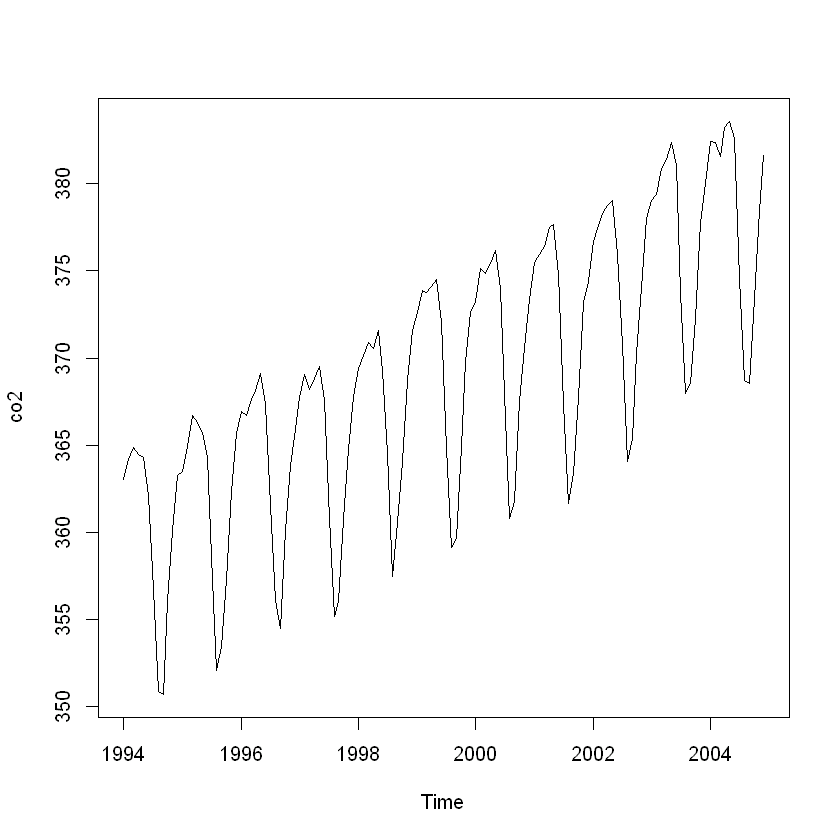

In [10]:
library(TSA)
data(co2)
plot(co2)

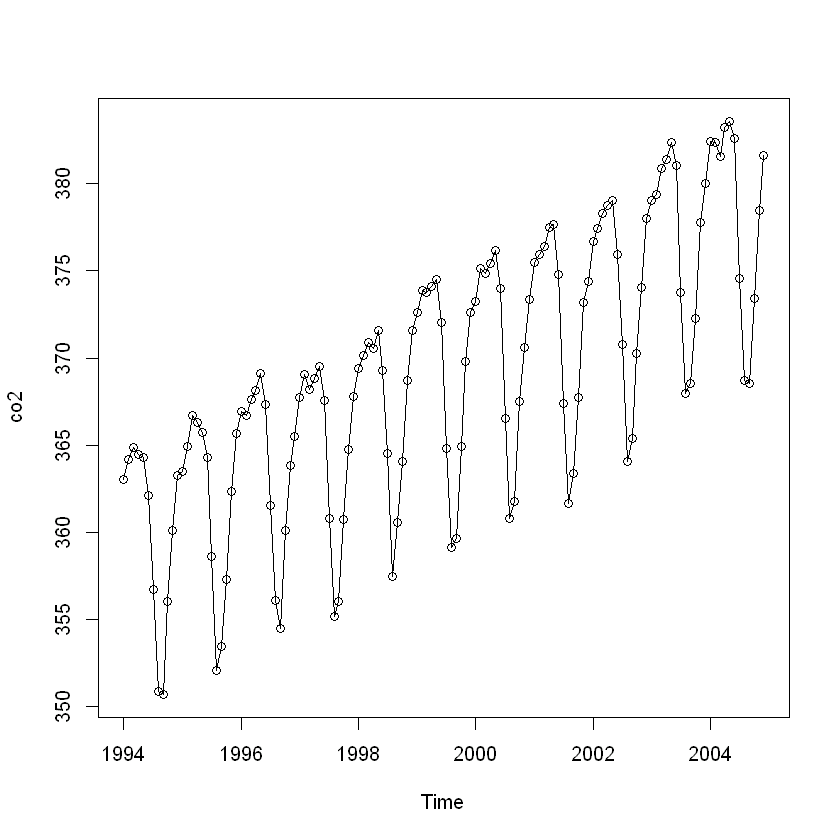

In [11]:
plot(co2, type='o')


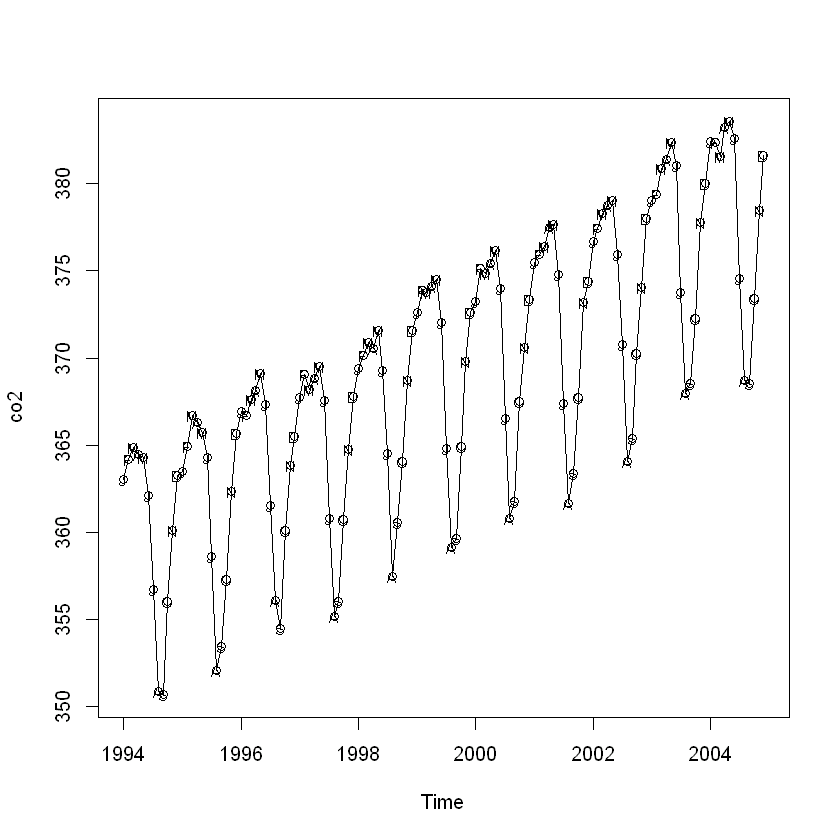

In [12]:
plot(co2, type='l')
points(y=co2, x=time(co2))
points(y=co2, x=time(co2), pch=as.vector(season(co2)), cex=0.75)


Call:
lm(formula = co2 ~ time(co2))

Residuals:
    Min      1Q  Median      3Q     Max 
-11.096  -4.284   2.321   4.306   6.554 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3127.2413   293.4126  -10.66   <2e-16 ***
time(co2)       1.7486     0.1467   11.92   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 5.354 on 130 degrees of freedom
Multiple R-squared:  0.522,	Adjusted R-squared:  0.5184 
F-statistic:   142 on 1 and 130 DF,  p-value: < 2.2e-16


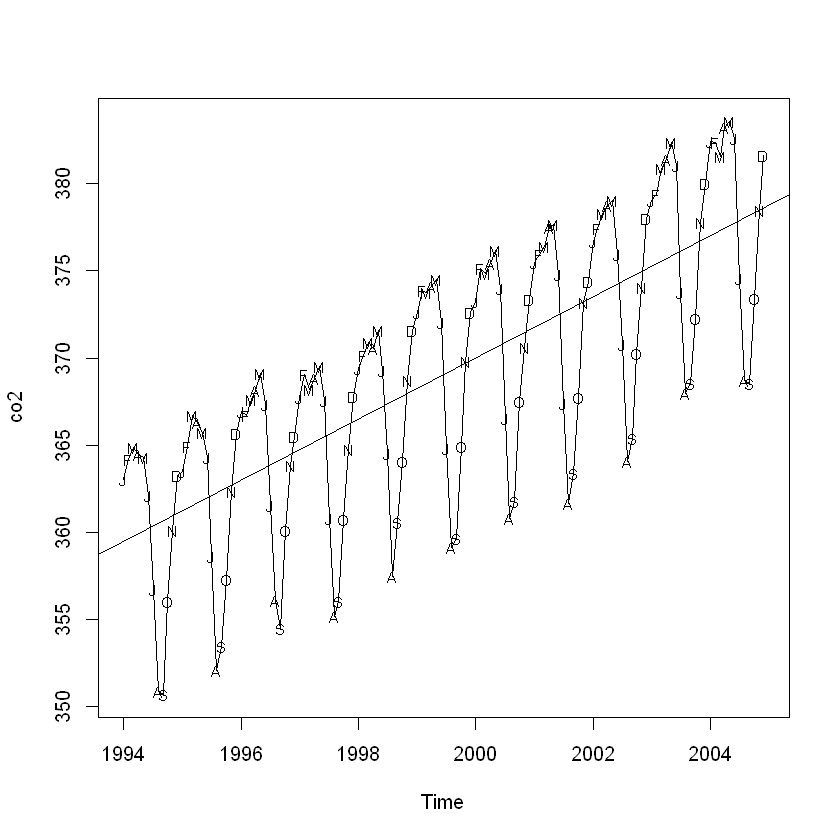

In [13]:
model = lm(co2 ~ time(co2))
summary(model)
plot(co2, type='l')
abline(model)
points(y=co2, x=time(co2), pch=as.vector(season(co2)), cex=0.75)

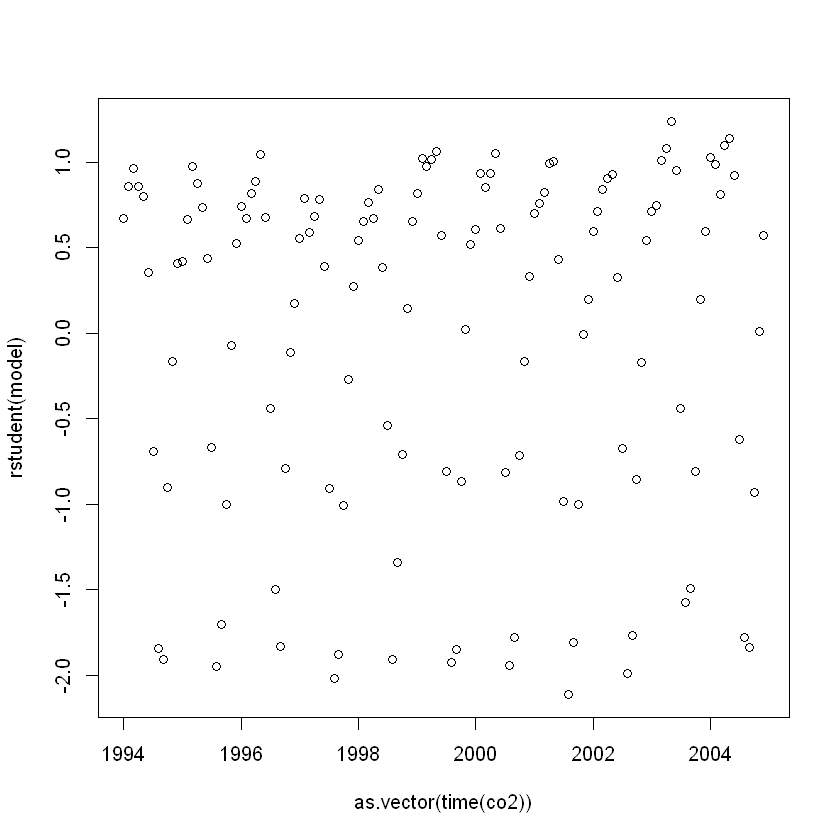

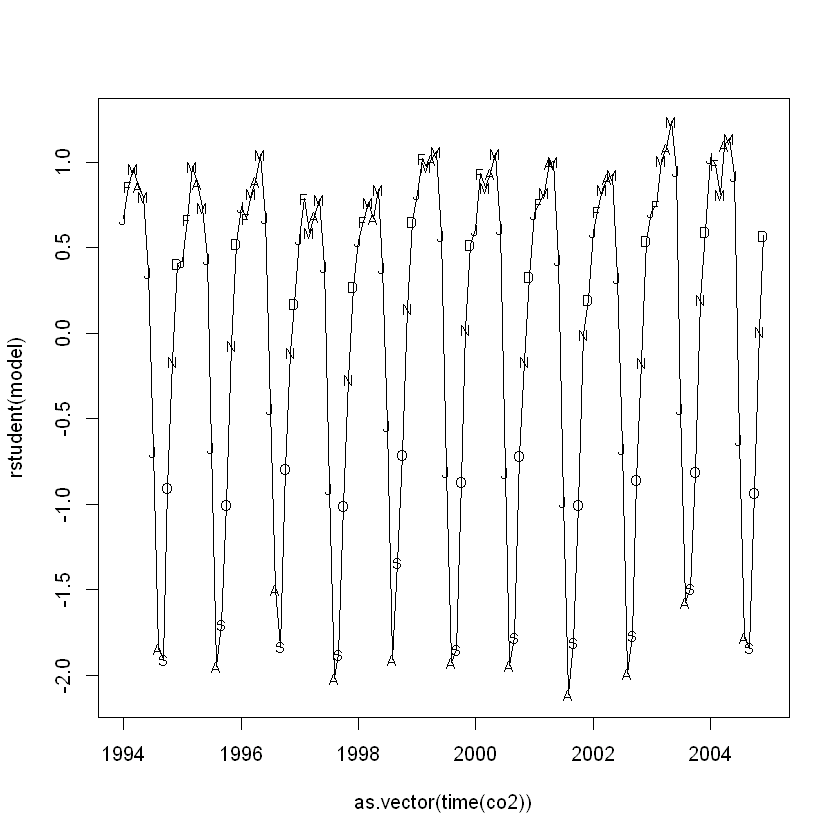

In [14]:
plot(y=rstudent(model), x=as.vector(time(co2)))
plot(y=rstudent(model), x=as.vector(time(co2)), type='l')
points(y=rstudent(model), x=as.vector(time(co2)), pch=as.vector(season(co2)), cex=0.75)

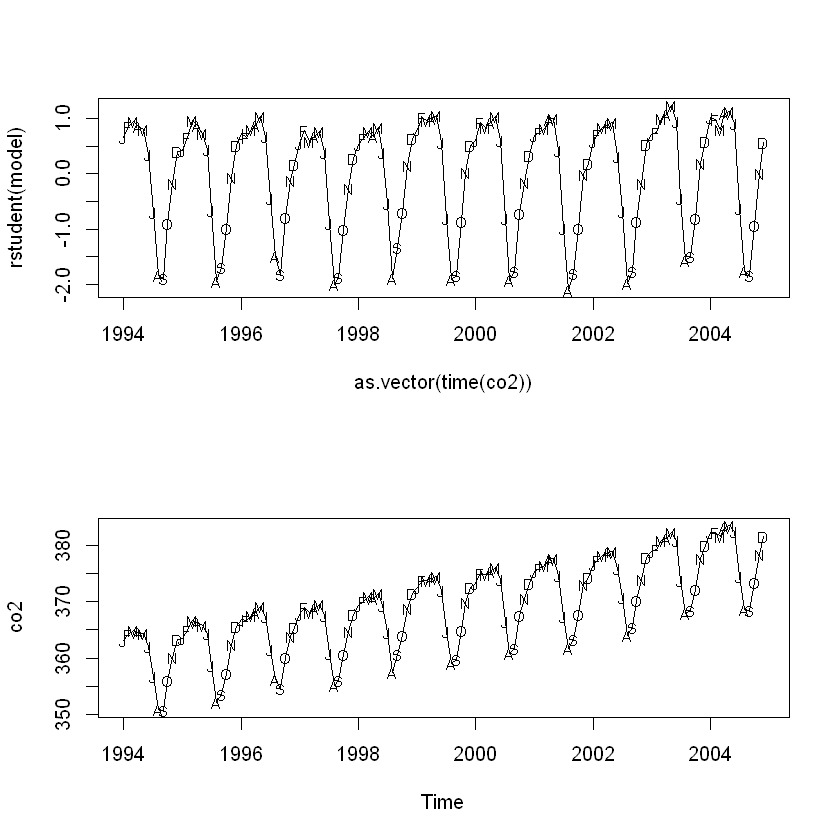

In [15]:
par(mfrow=c(2,1))
plot(y=rstudent(model), x=as.vector(time(co2)), type='l')
points(y=rstudent(model), x=as.vector(time(co2)), pch=as.vector(season(co2)), cex=0.75)
plot(co2, type='l')
points(y=co2, x=time(co2), pch=as.vector(season(co2)), cex=0.75)

 - as we can see from plot1 of residuals Yt - ~Yt (bo + b1.t) = et not white noise the seasonality is not captured
 - use diffrent model

 - ct = b0 + b1.t  +  b2.cos(2.pi.f.t) + b3.sin(2.pi.f.t) + Xt

 - so we added seaonality term and also we assumed that Xt must not be WN

 - E[Xt] = 0, taking f = 1 since we have 12 observations per year !!

 - f = 1 since the data repeats once per year !


Call:
lm(formula = co2 ~ har + time(co2))

Residuals:
    Min      1Q  Median      3Q     Max 
-5.1804 -1.7916 -0.1045  1.8986  5.1809 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -3.332e+03  1.280e+02  -26.03   <2e-16 ***
harcos(2*pi*t)  3.851e+00  2.868e-01   13.43   <2e-16 ***
harsin(2*pi*t)  5.596e+00  2.874e-01   19.47   <2e-16 ***
time(co2)       1.851e+00  6.401e-02   28.91   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.329 on 128 degrees of freedom
Multiple R-squared:  0.9109,	Adjusted R-squared:  0.9088 
F-statistic: 436.3 on 3 and 128 DF,  p-value: < 2.2e-16


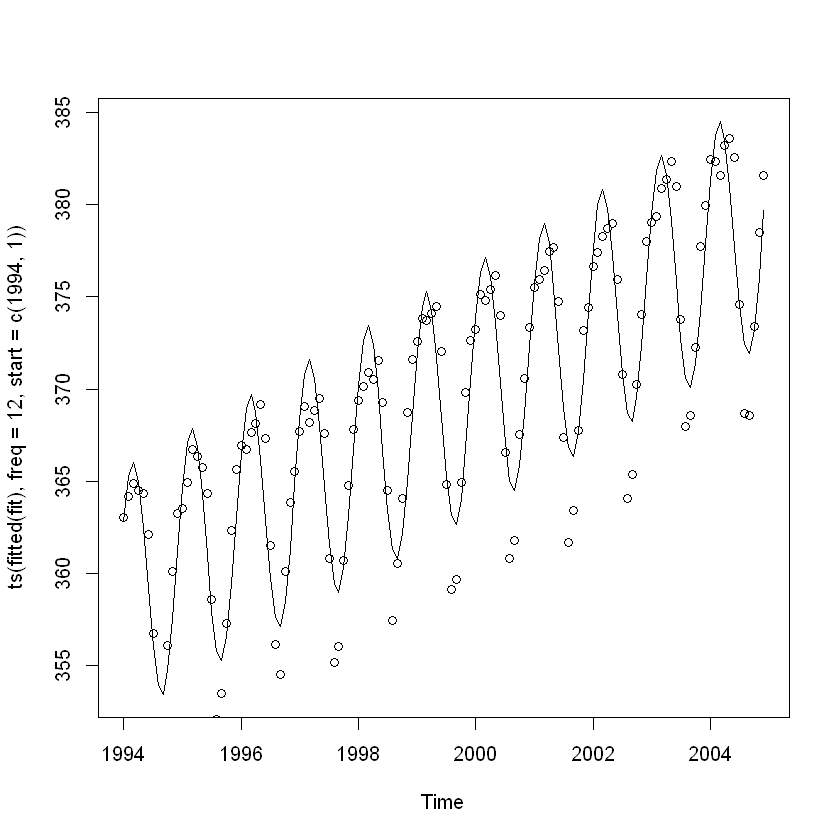

harmonic                  package:TSA                  R Documentation

_C_o_n_s_t_r_u_c_t _h_a_r_m_o_n_i_c _f_u_n_c_t_i_o_n_s _f_o_r _f_i_t_t_i_n_g _h_a_r_m_o_n_i_c _t_r_e_n_d _m_o_d_e_l

_D_e_s_c_r_i_p_t_i_o_n:

     The function creates a matrix of the first m pairs of harmonic
     functions for fitting a harmonic trend (cosine-sine trend, Fourier
     regresssion) models with the response being x, a time series.

_U_s_a_g_e:

     harmonic(x, m = 1)
     
_A_r_g_u_m_e_n_t_s:

       x: a time series

       m: the number of pairs of harmonic functions to be created; 2m
          must be less than or equal to the frequency of x

_V_a_l_u_e:

     a matrix consisting of \cos(2k pi t), \sin(2k pi t), k=1,2,...,m,
     excluding any zero functions.

_A_u_t_h_o_r(_s):

     Kung-Sik Chan

_S_e_e _A_l_s_o:

     'season'

_E_x_a_m_p_l_e_s:

     data(tempdub)
     # first creates th

In [16]:
har <- harmonic(co2, 1) 
help(harmonic)
fit <- lm(co2~har + time(co2))
summary(fit)
par(mfrow=c(1,1))
plot(ts(fitted(fit), freq=12, start=c(1994,1)), type='l')
points(co2)

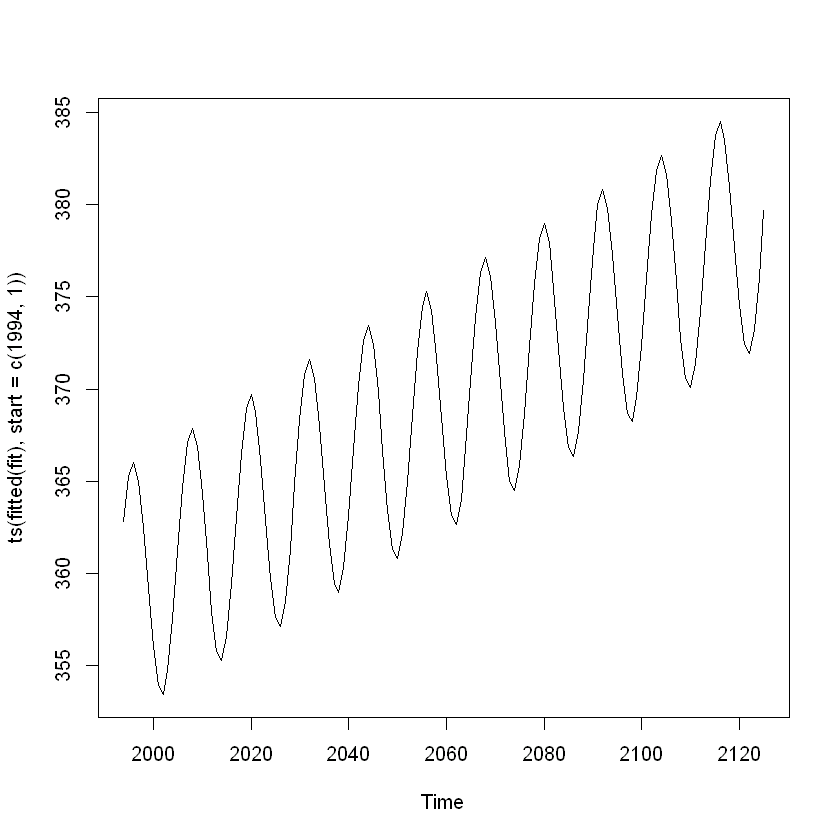

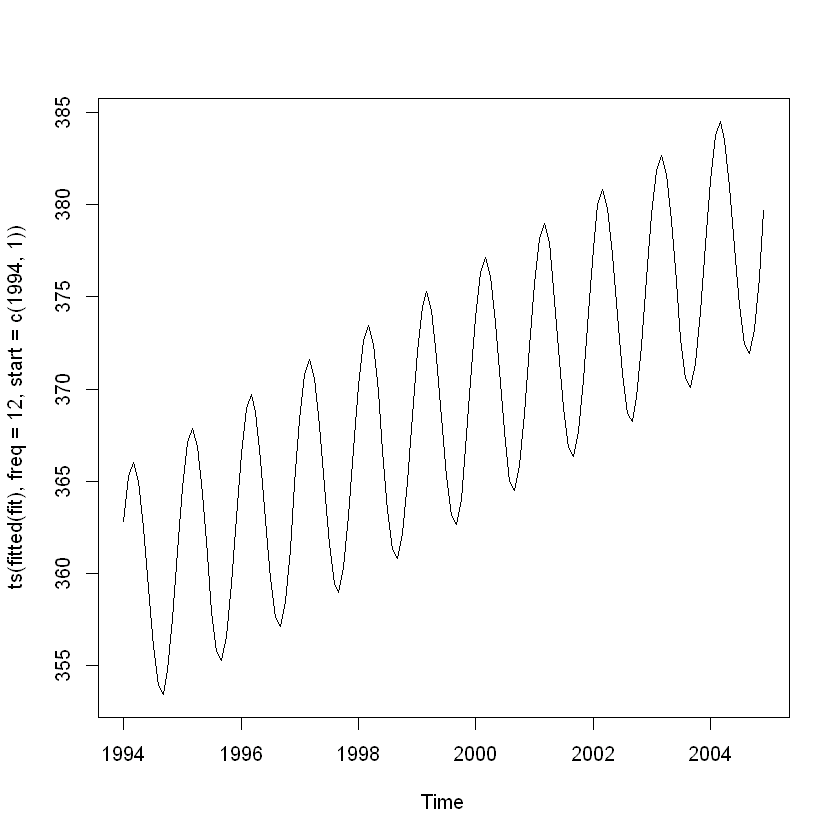

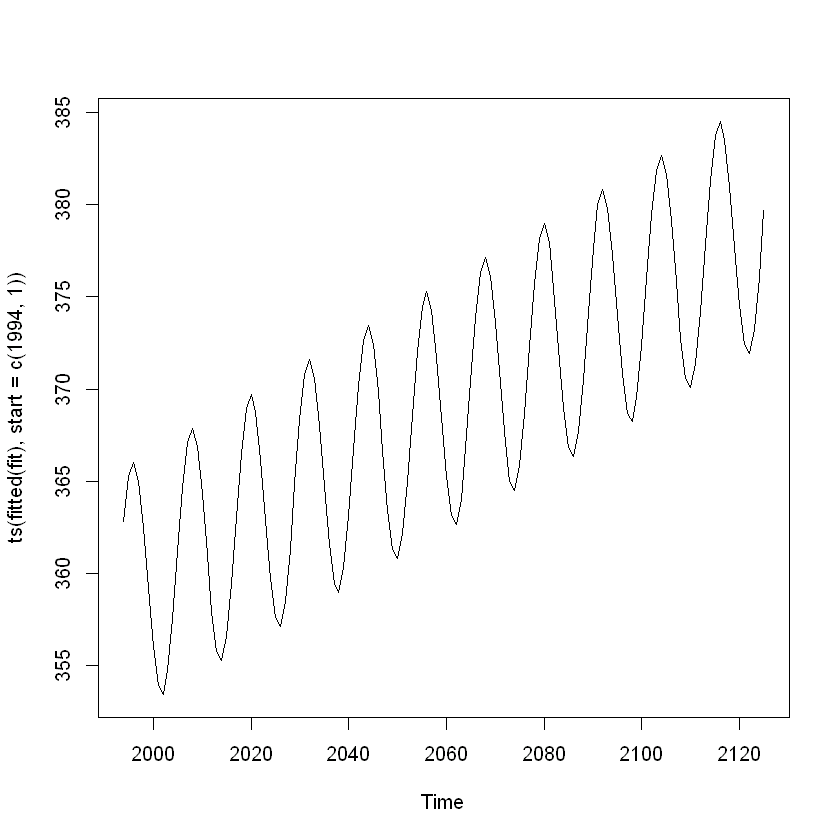

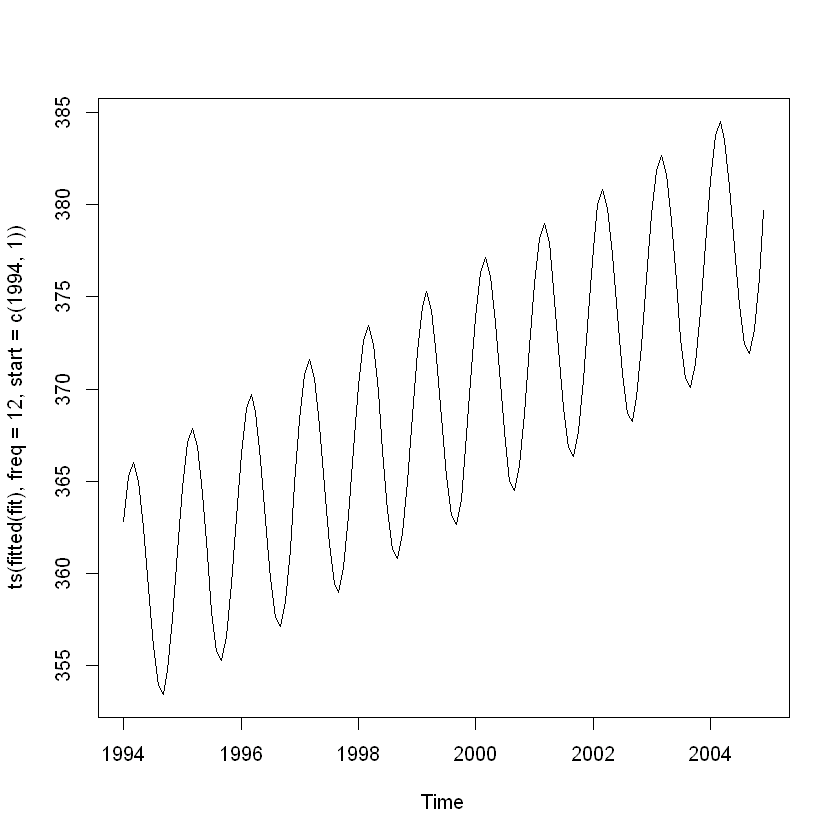

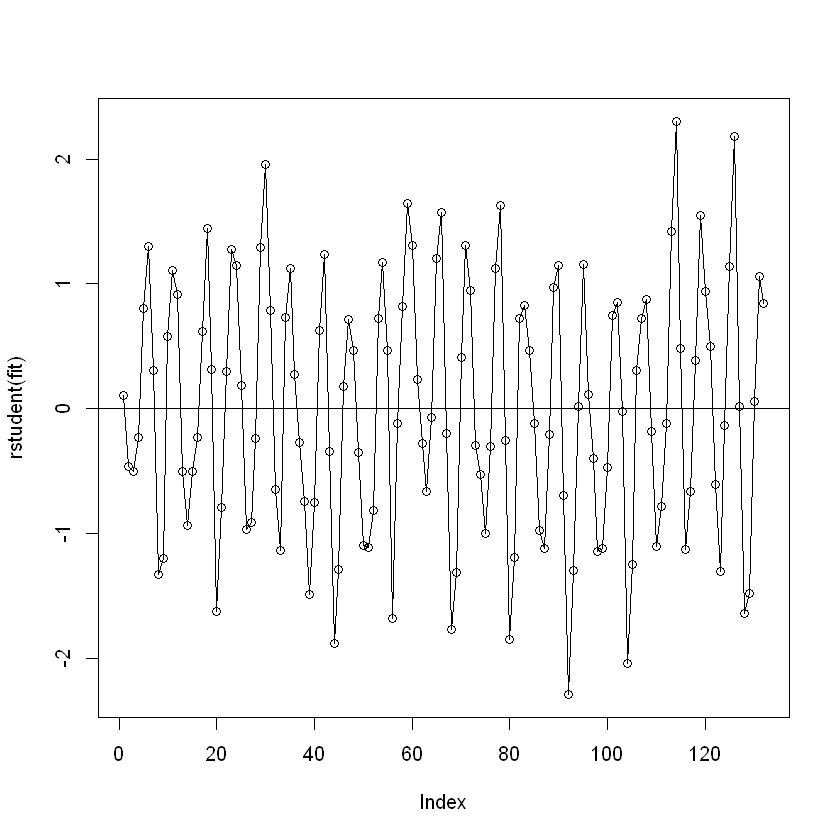

logical(0)

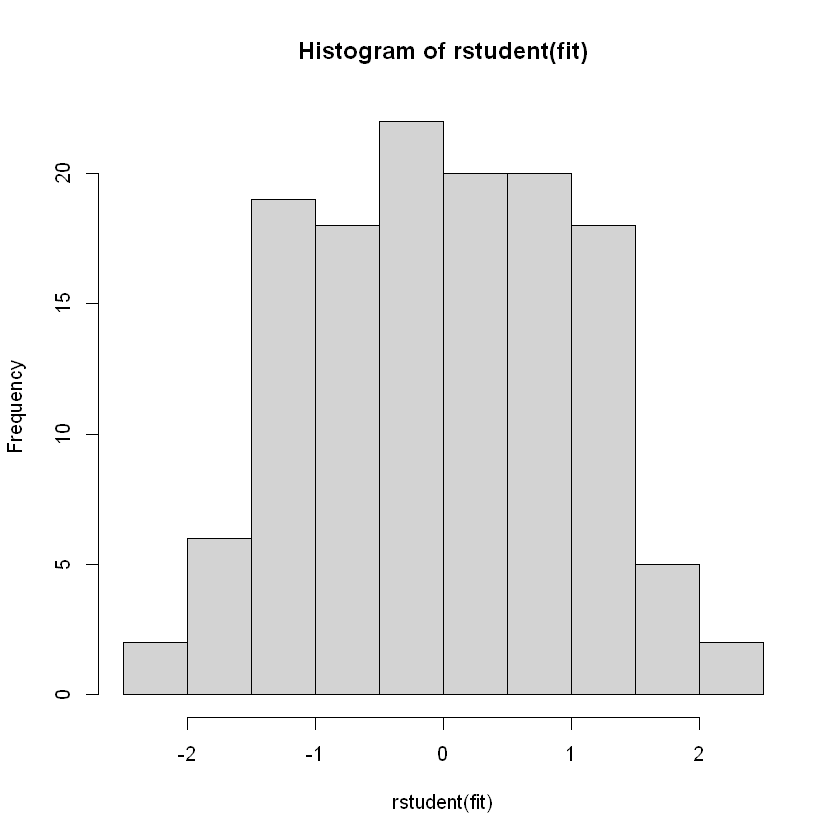

In [17]:
plot(ts(fitted(fit), start=c(1994,1)), type='l')
plot(ts(fitted(fit), freq=12, start=c(1994,1)), type='l')
plot(ts(fitted(fit), start=c(1994,1)), type='l')
plot(ts(fitted(fit), freq=12, start=c(1994,1)), type='l')
plot(rstudent(fit), type='o')
abline(h=0)>hist(rstudent(fit))

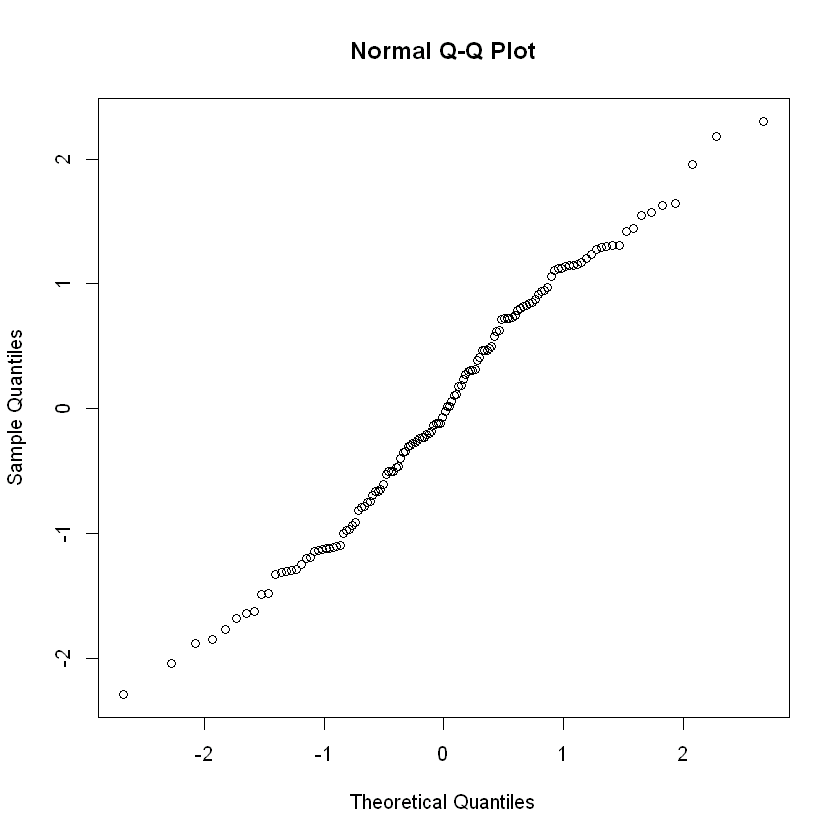

In [22]:
qqnorm(rstudent(fit))

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



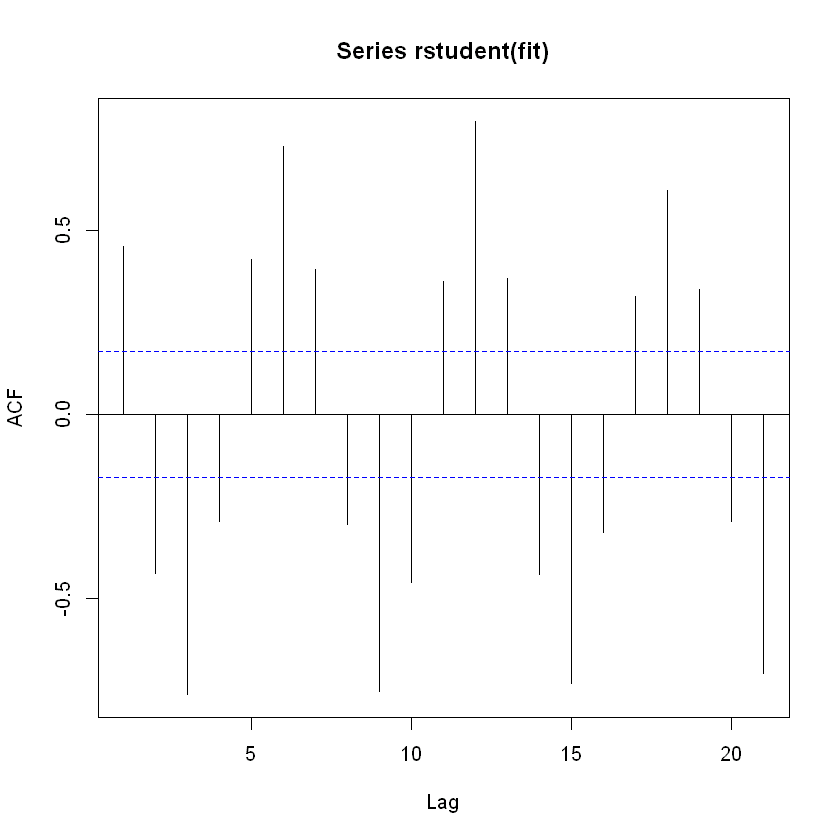

In [23]:
acf(rstudent(fit))
#runs.test(rstudent(fit))
library(tseries)
#runs.test(rstudent(fit))
res <- rstudent(fit)
res_sign <- factor(ifelse(res>0, "+","-"))
#runs.test(res_sign)